In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest
from scipy.stats import ttest_ind, chi2_contingency

from statsmodels.tsa.holtwinters import ExponentialSmoothing
import statsmodels.api as sm

from mlxtend.frequent_patterns import apriori, association_rules

import folium
from geopy.geocoders import Nominatim

In [2]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

In [3]:
df_list = []
for month in months:
    df = pd.read_csv(f"datasets/Sales_{month}_2019.csv")
    df = df.dropna(how='all')
    df["Month"] = month
    df_list.append(df)

merged_df = pd.concat(df_list, axis=0)

In [4]:
merged_df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215",January
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035",January
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016",January
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001",January
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301",January


In [5]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186305 entries, 0 to 25116
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
 6   Month             186305 non-null  object
dtypes: object(7)
memory usage: 11.4+ MB


In [6]:
merged_df.describe()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
count,186305,186305,186305,186305,186305,186305,186305
unique,178438,20,10,24,142396,140788,12
top,Order ID,USB-C Charging Cable,1,11.95,Order Date,Purchase Address,December
freq,355,21903,168552,21903,355,355,25037


In [7]:
merged_df = merged_df[(merged_df['Order ID'] != 'Order ID') | (merged_df['Order Date'] != 'Order Date') | (merged_df['Purchase Address'] != 'Purchase Address')]

In [8]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185950 entries, 0 to 25116
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          185950 non-null  object
 1   Product           185950 non-null  object
 2   Quantity Ordered  185950 non-null  object
 3   Price Each        185950 non-null  object
 4   Order Date        185950 non-null  object
 5   Purchase Address  185950 non-null  object
 6   Month             185950 non-null  object
dtypes: object(7)
memory usage: 11.3+ MB


In [9]:
merged_df.describe()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
count,185950,185950,185950,185950,185950,185950,185950
unique,178437,19,9,23,142395,140787,12
top,160873,USB-C Charging Cable,1,11.95,12/15/19 20:16,"193 Forest St, San Francisco, CA 94016",December
freq,5,21903,168552,21903,8,9,24989


In [10]:
# Remove duplicated rows
merged_df = merged_df.drop_duplicates()

# Convert datatypes
merged_df['Quantity Ordered'] = merged_df['Quantity Ordered'].astype(int)
merged_df['Price Each'] = merged_df['Price Each'].astype(float)

# Create Sales Column
merged_df['Sales'] = merged_df['Quantity Ordered'] * merged_df['Price Each']

# Convert Order Date to datetime
merged_df['Order Date'] = pd.to_datetime(merged_df['Order Date'], errors='coerce')

# Extract Hour and Day
merged_df['Hour'] = merged_df['Order Date'].dt.hour
merged_df['Day'] = merged_df['Order Date'].dt.day
merged_df['DayOfWeek'] = merged_df['Order Date'].dt.day_name()

merged_df.head()


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_20884\2184036082.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df['Order Date'] = pd.to_datetime(merged_df['Order Date'], errors='coerce')


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,Hour,Day,DayOfWeek
0,141234,iPhone,1,700.00,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",January,700.00,21,22,Tuesday
1,141235,Lightning Charging Cable,1,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",January,14.95,14,28,Monday
2,141236,Wired Headphones,2,11.99,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",January,23.98,13,17,Thursday
3,141237,27in FHD Monitor,1,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",January,149.99,20,5,Saturday
4,141238,Wired Headphones,1,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",January,11.99,11,25,Friday


In [11]:
merged_df.to_csv("Sales_2019.csv")

In [132]:
sales_per_month = merged_df.groupby('Month')['Sales'].sum()

print(sales_per_month)


Month
April        3394606.85
August       2241027.80
December     4614149.48
February     2201536.90
January      1814491.55
July         2645585.25
June         2576771.19
March        2806936.27
May          3142594.28
November     3197181.08
October      3734935.03
September    2095722.26
Name: Sales, dtype: float64


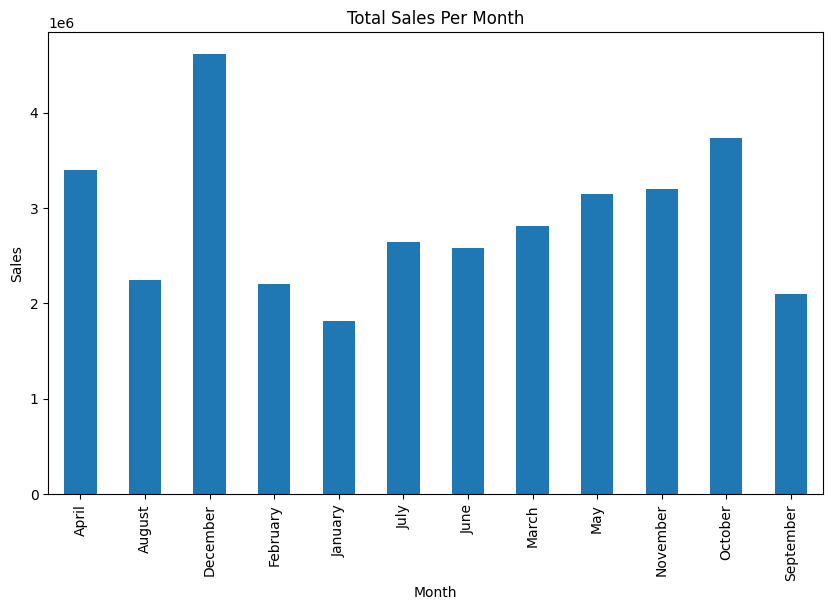

In [133]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sales_per_month.plot(kind='bar')
plt.ylabel("Sales")
plt.title("Total Sales Per Month")
plt.show()


In [134]:
quantity_product = merged_df.groupby('Product')['Quantity Ordered'].sum()
print(quantity_product)

Product
20in Monitor                   4126
27in 4K Gaming Monitor         6239
27in FHD Monitor               7541
34in Ultrawide Monitor         6192
AA Batteries (4-pack)         27615
AAA Batteries (4-pack)        30986
Apple Airpods Headphones      15637
Bose SoundSport Headphones    13430
Flatscreen TV                  4813
Google Phone                   5529
LG Dryer                        646
LG Washing Machine              666
Lightning Charging Cable      23169
Macbook Pro Laptop             4725
ThinkPad Laptop                4128
USB-C Charging Cable          23931
Vareebadd Phone                2068
Wired Headphones              20524
iPhone                         6847
Name: Quantity Ordered, dtype: int64


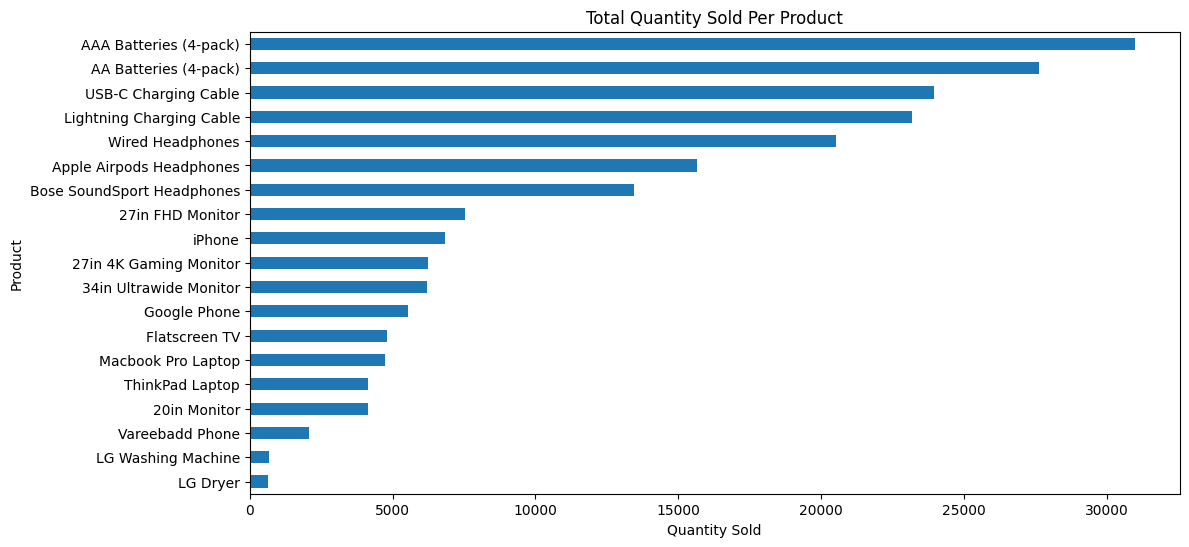

In [135]:
plt.figure(figsize=(12,6))
quantity_product.sort_values(ascending=True).plot(kind='barh')
plt.ylabel("Product")
plt.xlabel("Quantity Sold")
plt.title("Total Quantity Sold Per Product")
plt.show()


In [136]:
product_sales = merged_df.groupby("Product")['Sales'].sum()
print(product_sales)


Product
20in Monitor                   453818.74
27in 4K Gaming Monitor        2433147.61
27in FHD Monitor              1131074.59
34in Ultrawide Monitor        2352898.08
AA Batteries (4-pack)          106041.60
AAA Batteries (4-pack)          92648.14
Apple Airpods Headphones      2345550.00
Bose SoundSport Headphones    1342865.70
Flatscreen TV                 1443900.00
Google Phone                  3317400.00
LG Dryer                       387600.00
LG Washing Machine             399600.00
Lightning Charging Cable       346376.55
Macbook Pro Laptop            8032500.00
ThinkPad Laptop               4127958.72
USB-C Charging Cable           285975.45
Vareebadd Phone                827200.00
Wired Headphones               246082.76
iPhone                        4792900.00
Name: Sales, dtype: float64


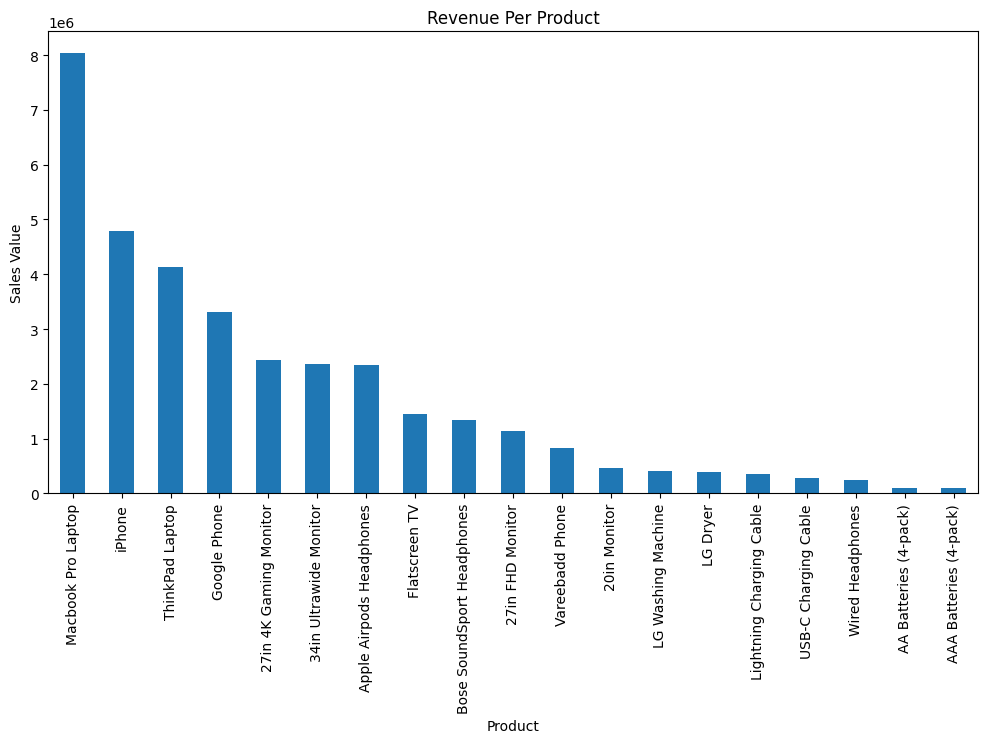

In [137]:
plt.figure(figsize=(12,6))
product_sales.sort_values(ascending=False).plot(kind='bar')
plt.xlabel("Product")
plt.ylabel("Sales Value")
plt.title("Revenue Per Product")
plt.show()


In [138]:
orders_by_hour = merged_df.groupby('Hour')['Order ID'].count()
print(orders_by_hour)


Hour
0      3902
1      2347
2      1242
3       830
4       852
5      1320
6      2481
7      4002
8      6252
9      8740
10    10929
11    12392
12    12573
13    12115
14    10965
15    10159
16    10359
17    10884
18    12263
19    12886
20    12218
21    10905
22     8808
23     6262
Name: Order ID, dtype: int64


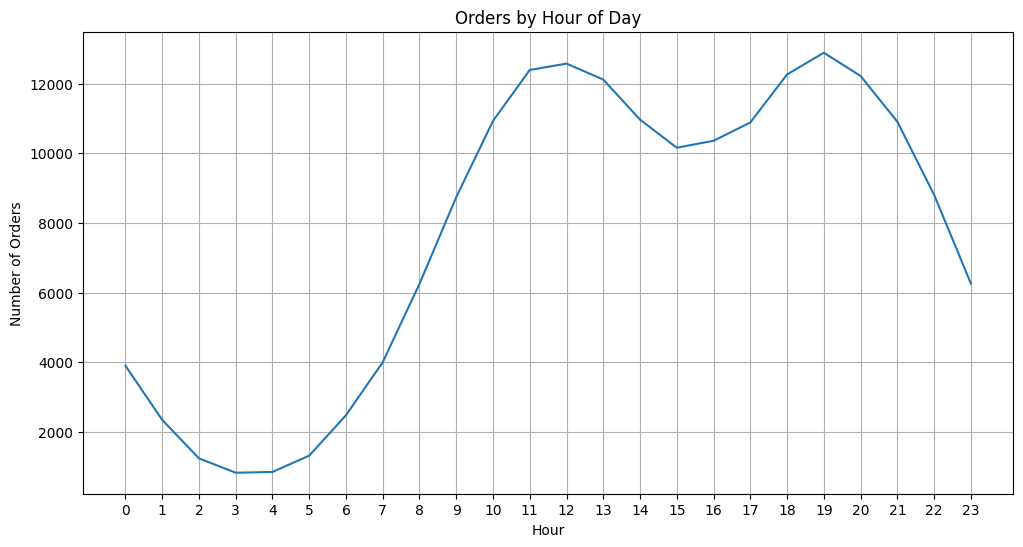

In [139]:
plt.figure(figsize=(12,6))
orders_by_hour.plot()
plt.xticks(range(0,24))
plt.xlabel("Hour")
plt.ylabel("Number of Orders")
plt.title("Orders by Hour of Day")
plt.grid()
plt.show()


In [140]:
orders_by_day = merged_df.groupby("DayOfWeek")['Order ID'].count()
print(orders_by_day)


DayOfWeek
Friday       26214
Monday       26508
Saturday     26453
Sunday       26518
Thursday     26418
Tuesday      27137
Wednesday    26438
Name: Order ID, dtype: int64


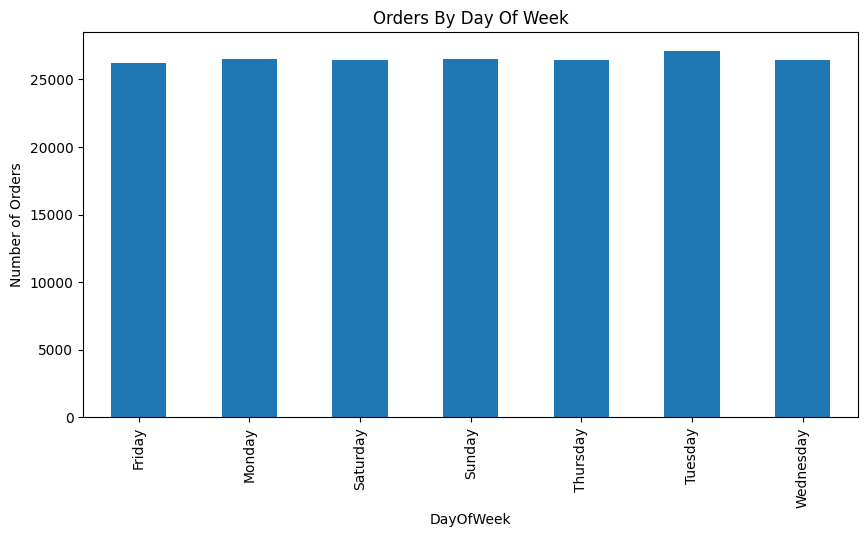

In [141]:
plt.figure(figsize=(10,5))
orders_by_day.plot(kind='bar')
plt.title("Orders By Day Of Week")
plt.ylabel("Number of Orders")
plt.show()


In [142]:
merged_df['City'] = merged_df['Purchase Address'].apply(lambda x: x.split(',')[1].strip())
merged_df[['Purchase Address','City']].head()


,Purchase Address,City
0,"944 Walnut St, Boston, MA 02215",Boston
1,"185 Maple St, Portland, OR 97035",Portland
2,"538 Adams St, San Francisco, CA 94016",San Francisco
3,"738 10th St, Los Angeles, CA 90001",Los Angeles
4,"387 10th St, Austin, TX 73301",Austin


In [143]:
sales_by_city = merged_df.groupby("City")['Sales'].sum()
print(sales_by_city)


City
Atlanta          2794199.07
Austin           1818044.33
Boston           3658627.65
Dallas           2765373.96
Los Angeles      5448304.28
New York City    4661867.14
Portland         2319331.94
San Francisco    8254743.55
Seattle          2745046.02
Name: Sales, dtype: float64


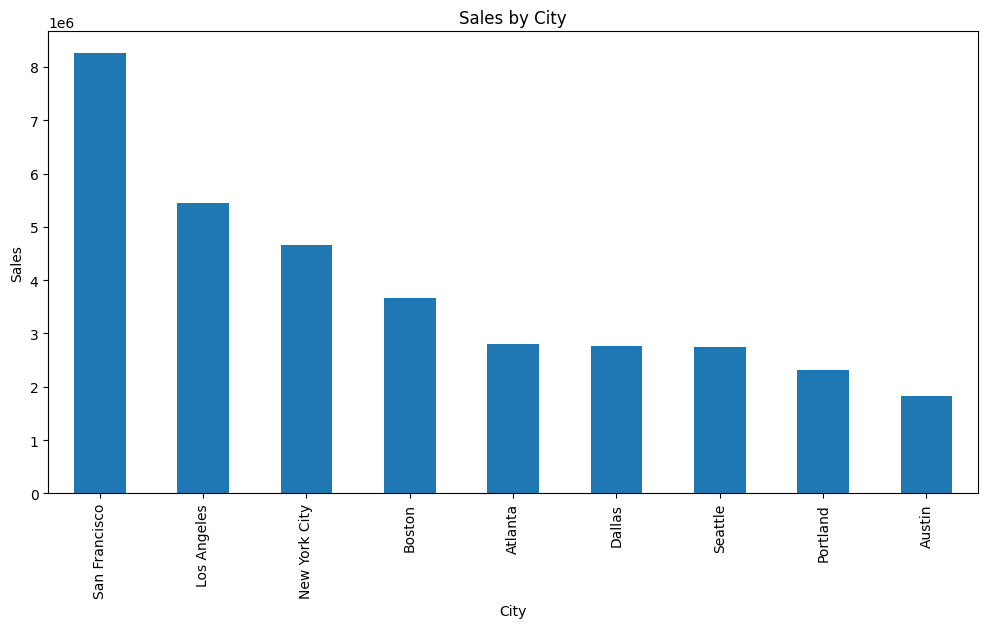

In [144]:
plt.figure(figsize=(12,6))
sales_by_city.sort_values(ascending=False).plot(kind='bar')
plt.xlabel("City")
plt.ylabel("Sales")
plt.title("Sales by City")
plt.show()


In [145]:
df_dup = merged_df[merged_df['Order ID'].duplicated(keep=False)]
df_dup['Grouped'] = df_dup.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))
df_grouped = df_dup[['Order ID','Grouped']].drop_duplicates()

from collections import Counter
count = Counter()

for group in df_grouped['Grouped']:
    items = group.split(',')
    count.update(Counter(tuple(sorted(items)) for item in items))

count.most_common(10)


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_42300\653788777.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dup['Grouped'] = df_dup.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))


[(('Lightning Charging Cable', 'iPhone'), 1790),
 (('Google Phone', 'USB-C Charging Cable'), 1738),
 (('Wired Headphones', 'iPhone'), 748),
 (('USB-C Charging Cable', 'Vareebadd Phone'), 636),
 (('Google Phone', 'Wired Headphones'), 622),
 (('Apple Airpods Headphones', 'iPhone'), 598),
 (('Bose SoundSport Headphones', 'Google Phone'), 338),
 (('Google Phone', 'USB-C Charging Cable', 'Wired Headphones'), 240),
 (('Vareebadd Phone', 'Wired Headphones'), 220),
 (('AA Batteries (4-pack)', 'Lightning Charging Cable'), 206)]

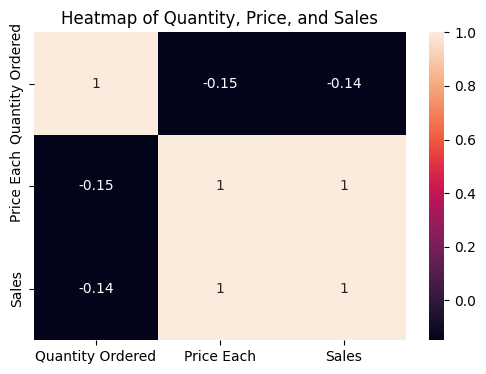

In [146]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(merged_df[['Quantity Ordered','Price Each','Sales']].corr(), annot=True)
plt.title("Heatmap of Quantity, Price, and Sales")
plt.show()


Product Clustering

In [147]:
product_cluster_df = merged_df.groupby('Product').agg({
    'Quantity Ordered': 'sum',
    'Sales': 'sum',
    'Price Each': 'mean'
})

product_cluster_df


,Quantity Ordered,Sales,Price Each
Product,,,
20in Monitor,4126,453818.74,109.99
27in 4K Gaming Monitor,6239,2433147.61,389.99
27in FHD Monitor,7541,1131074.59,149.99
34in Ultrawide Monitor,6192,2352898.08,379.99
AA Batteries (4-pack),27615,106041.60,3.84
AAA Batteries (4-pack),30986,92648.14,2.99
Apple Airpods Headphones,15637,2345550.00,150.00
Bose SoundSport Headphones,13430,1342865.70,99.99
Flatscreen TV,4813,1443900.00,300.00


In [148]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(product_cluster_df)

kmeans = KMeans(n_clusters=3, random_state=0)
product_cluster_df['Cluster'] = kmeans.fit_predict(scaled)
product_cluster_df


,Quantity Ordered,Sales,Price Each,Cluster
Product,,,,
20in Monitor,4126,453818.74,109.99,0
27in 4K Gaming Monitor,6239,2433147.61,389.99,0
27in FHD Monitor,7541,1131074.59,149.99,0
34in Ultrawide Monitor,6192,2352898.08,379.99,0
AA Batteries (4-pack),27615,106041.60,3.84,1
AAA Batteries (4-pack),30986,92648.14,2.99,1
Apple Airpods Headphones,15637,2345550.00,150.00,1
Bose SoundSport Headphones,13430,1342865.70,99.99,1
Flatscreen TV,4813,1443900.00,300.00,0


Price Elasticity Analysis

In [149]:
x = merged_df[['Price Each']].astype(float)
y = merged_df['Quantity Ordered'].astype(float)

model = LinearRegression()
model.fit(x,y)

print("Elasticity Coefficient:", model.coef_[0])


Elasticity Coefficient: -0.00019757298133484113


GeoHeatmap

In [150]:
merged_df['City'] = merged_df['Purchase Address'].apply(lambda x: x.split(',')[1].strip())
city_sales = merged_df.groupby('City')['Sales'].sum()
city_sales


City
Atlanta          2794199.07
Austin           1818044.33
Boston           3658627.65
Dallas           2765373.96
Los Angeles      5448304.28
New York City    4661867.14
Portland         2319331.94
San Francisco    8254743.55
Seattle          2745046.02
Name: Sales, dtype: float64

In [151]:
m = folium.Map(location=[37, -95], zoom_start=4)
geolocator = Nominatim(user_agent="geo")

for city, sales in city_sales.items():
    try:
        loc = geolocator.geocode(city)
        folium.CircleMarker(location=[loc.latitude, loc.longitude],
                            radius=10,
                            popup=f"{city}: ${sales:.2f}").add_to(m)
    except:
        pass

m


Anomaly Detection

In [152]:
iso = IsolationForest(contamination=0.01)
merged_df['Anomaly'] = iso.fit_predict(merged_df[['Sales']])
merged_df[merged_df['Anomaly'] == -1]


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,Hour,Day,DayOfWeek,City,Anomaly
4717,181069,Macbook Pro Laptop,2,1700.0,2019-04-27 21:01:00,"668 Park St, San Francisco, CA 94016",April,3400.0,21,27,Saturday,San Francisco,-1
5219,181544,Macbook Pro Laptop,2,1700.0,2019-04-22 12:48:00,"731 11th St, New York City, NY 10001",April,3400.0,12,22,Monday,New York City,-1
6776,200528,Macbook Pro Laptop,2,1700.0,2019-05-13 13:40:00,"643 4th St, Boston, MA 02215",May,3400.0,13,13,Monday,Boston,-1
385,210292,Macbook Pro Laptop,2,1700.0,2019-06-08 09:00:00,"953 Ridge St, San Francisco, CA 94016",June,3400.0,9,8,Saturday,San Francisco,-1


Demand

In [153]:
month_dict = {'January':1, 'February':2, 'March':3, 'April':4,
              'May':5, 'June':6, 'July':7, 'August':8,
              'September':9, 'October':10, 'November':11, 'December':12}

dm = merged_df[['Quantity Ordered','Price Each','Month']].copy()
dm['MonthNum'] = dm['Month'].map(month_dict)

X = dm[['Price Each','MonthNum']]
y = dm['Quantity Ordered']

reg = LinearRegression()
reg.fit(X,y)

print("Coefficients:", reg.coef_)
print("Intercept:", reg.intercept_)

Coefficients: [-1.97570937e-04  5.95215148e-05]
Intercept: 1.1605790297134124


Optimization Simulation

In [154]:
city_behavior = merged_df.groupby(['City','Product'])['Sales'].sum().unstack().fillna(0)
city_behavior


Product,20in Monitor,27in 4K Gaming Monitor,27in FHD Monitor,34in Ultrawide Monitor,AA Batteries (4-pack),AAA Batteries (4-pack),Apple Airpods Headphones,Bose SoundSport Headphones,Flatscreen TV,Google Phone,LG Dryer,LG Washing Machine,Lightning Charging Cable,Macbook Pro Laptop,ThinkPad Laptop,USB-C Charging Cable,Vareebadd Phone,Wired Headphones,iPhone
City,,,,,,,,,,,,,,,,,,,
Atlanta,37506.59,191875.08,88044.13,183155.18,8421.12,7050.42,189900.0,108189.18,121800.0,270600.0,35400.0,31200.0,28016.30,644300.0,356996.43,22848.40,69200.0,18896.24,380800.0
Austin,25297.70,123626.83,53696.42,124636.72,5460.48,4987.32,132600.0,70692.93,72300.0,164400.0,33000.0,15600.0,19509.75,426700.0,209997.90,14925.55,43200.0,13512.73,263900.0
Boston,43336.06,263243.25,119542.03,254593.30,11562.24,10339.42,247650.0,141085.89,165900.0,355200.0,35400.0,43200.0,37105.90,814300.0,446995.53,30532.25,85600.0,26641.78,526400.0
Dallas,37616.58,187585.19,88044.13,194554.88,8678.40,7475.00,178950.0,105789.42,126000.0,276600.0,26400.0,30600.0,27836.90,647700.0,344996.55,22095.55,71200.0,19951.36,363300.0
Los Angeles,72373.42,391159.97,183287.78,362890.45,17026.56,14824.42,370200.0,212078.79,218100.0,508800.0,69600.0,63000.0,56286.75,1275000.0,639993.60,45123.20,126800.0,39159.34,782600.0
New York City,61594.40,327981.59,160789.28,329451.33,13935.36,12315.81,314100.0,179082.09,188400.0,454200.0,46200.0,51000.0,45433.05,1116900.0,559994.40,38992.85,112400.0,32396.98,616700.0
Portland,30467.23,169255.66,79344.71,153135.97,7445.76,6213.22,164550.0,88691.13,93300.0,213000.0,22200.0,22200.0,22843.60,572900.0,273997.26,18881.00,49600.0,16306.40,315000.0
San Francisco,109990.00,568605.42,271481.90,548325.57,25148.16,22137.96,559350.0,331166.88,345900.0,814200.0,85800.0,108000.0,82823.00,1929500.0,962990.37,70301.85,197600.0,59422.44,1162000.0
Seattle,35636.76,209814.62,86844.21,202154.68,8363.52,7304.57,188250.0,106089.39,112200.0,260400.0,33600.0,34800.0,26521.30,605200.0,331996.68,22274.80,71600.0,19795.49,382200.0
